In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [16]:
df=pd.read_csv("Apple_Stock.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100178,469033600
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.094952,175884800
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.087983,105728000
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090160,86441600
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092774,73449600


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10468 entries, 1980-12-12 to 2022-06-17
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       10468 non-null  float64
 1   High       10468 non-null  float64
 2   Low        10468 non-null  float64
 3   Close      10468 non-null  float64
 4   Adj Close  10468 non-null  float64
 5   Volume     10468 non-null  int64  
dtypes: float64(5), int64(1)
memory usage: 572.5 KB


In [17]:
df["Date"]=pd.to_datetime(df["Date"])
df=df.set_index("Date")

In [18]:
# After making 'Date' the time series Index-
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100178,469033600
1980-12-15,0.122210,0.122210,0.121652,0.121652,0.094952,175884800
1980-12-16,0.113281,0.113281,0.112723,0.112723,0.087983,105728000
1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090160,86441600
1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092774,73449600


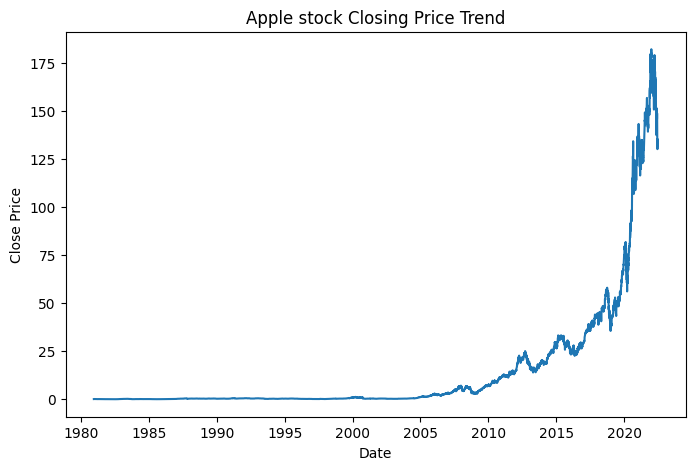

In [19]:
# Closing Price Trend

plt.figure(figsize=(8,5))
plt.plot(df["Close"])
plt.title("Apple stock Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

In [20]:
# Moving Averages

df["MA_30"]=df["Close"].rolling(window=30).mean()
df["MA_100"]=df["Close"].rolling(window=100).mean()

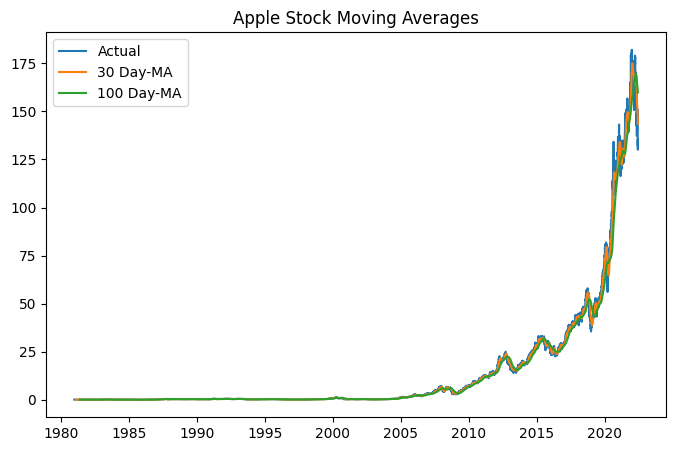

In [21]:
plt.figure(figsize=(8,5))
plt.plot(df["Close"], label="Actual")
plt.plot(df["MA_30"], label="30 Day-MA")
plt.plot(df["MA_100"], label="100 Day-MA")
plt.legend()
plt.title("Apple Stock Moving Averages")
plt.show()

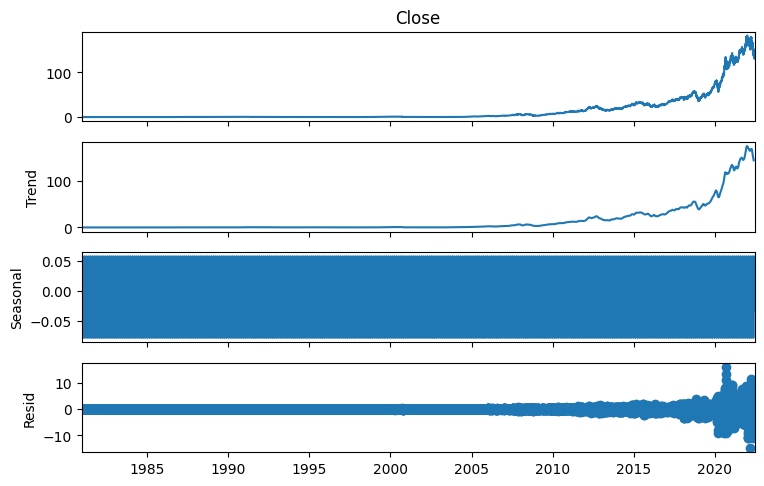

In [22]:
# Trend Decomposition

decomposition=seasonal_decompose(df["Close"],model="additive",period=30)
fig=decomposition.plot()
fig.set_size_inches(8,5)
plt.show()


In [23]:
# Train-Test Split

train=df["Close"].iloc[:-30]
test=df["Close"].iloc[-30:]

In [25]:
# ARIMA Forecasting

model=ARIMA(train,order=(2,1,2))
result=model.fit()
forecast=result.forecast(steps=30)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

In [26]:
rmse=np.sqrt(mean_squared_error(test,forecast))
print("RMSE:  ",rmse)

RMSE:   15.447029850775328


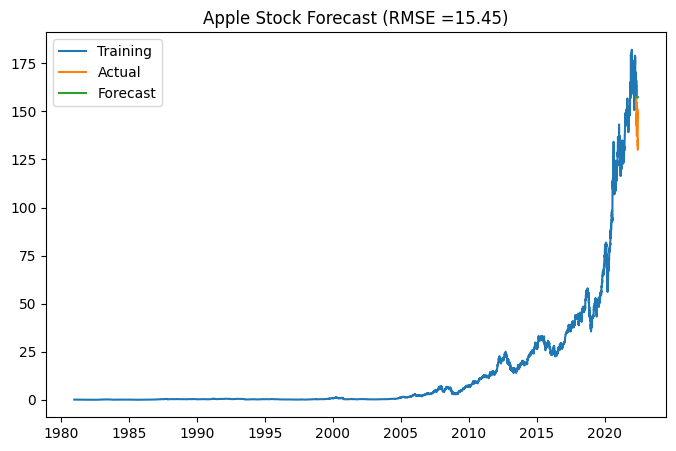

In [28]:
# Forecast Plot

plt.figure(figsize=(8,5))
plt.plot(train.index,train,label="Training")
plt.plot(test.index,test,label="Actual")
plt.plot(test.index,forecast,label="Forecast")
plt.legend()
plt.title(f"Apple Stock Forecast (RMSE ={rmse:.2f})")
plt.show()